## Homework 2 
## Author: Zihan Gao

### Problem 1: Backprop on a Residual MLP

We consider a residual MLP with $k=3$. The forward pass is
\begin{align}
h_0 &= x, \\
a_1 &= W_1^\top h_0 + b_1, \\
h_1 &= g(a_1) + h_0, \\
a_2 &= W_2^\top h_1 + b_2, \\
h_2 &= g(a_2) + h_1, \\
\hat{y} &= W_3^\top h_2 + b_3 .
\end{align}

The loss function is the mean-squared error
$$
L = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2 .
$$

(a)  
For a single data point,
$$
\frac{\partial L}{\partial \hat{y}} = \frac{2}{N}(\hat{y} - y).
$$

Since $\hat{y} = W_3^\top h_2 + b_3$, we have
\begin{align}
\frac{\partial L}{\partial W_3}
&= \frac{2}{N}(\hat{y} - y) h_2, \\
\frac{\partial L}{\partial b_3}
&= \frac{2}{N}(\hat{y} - y).
\end{align}

(b)  
Define
$$
e_\ell := \frac{\partial L}{\partial h_\ell}, \quad
\delta_\ell := \frac{\partial L}{\partial a_\ell}
= e_\ell \odot g'(a_\ell),
\quad \ell = 1,2 .
$$

From the residual relation
$$
h_\ell = g(a_\ell) + h_{\ell-1},
$$
$h_{\ell-1}$ affects the loss through the identity skip connection and through $a_\ell$.
Applying the chain rule,
$$
e_{\ell-1}
= e_\ell
+ \frac{\partial L}{\partial a_\ell}
\frac{\partial a_\ell}{\partial h_{\ell-1}}
= e_\ell + W_\ell \delta_\ell .
$$

Thus, for $\ell = 1,2$,
$$
e_{\ell-1} = e_\ell + W_\ell \delta_\ell .
$$


### Problem 2: Bias and Variance


1) Gradient:

$$
\nabla_\theta \ell_i(\theta)
=
2(\exp(\theta^\top X_i)-Y_i)
\exp(\theta^\top X_i)
X_i
$$

$$
\nabla_\theta L(\theta,D)
=
\frac{2}{N}\sum_{i=1}^N
(\exp(\theta^\top X_i)-Y_i)
\exp(\theta^\top X_i)
X_i
+
2\lambda\theta
$$

The verification shows that the two gradients are nearly identical in magnitude, indicating that the analytical computation is numerically correct.

2) Gradient descent update:
(The code is provided in the following code block)
$$
\theta
\leftarrow
\theta
-
\eta
\left(
\frac{2}{N}\sum_{i=1}^N
(\exp(\theta^\top X_i)-Y_i)
\exp(\theta^\top X_i)
X_i
+
2\lambda\theta
\right)
$$

3) 
Empirical estimators (M datasets):

we estimate MSE, bias, and variance using Monte Carlo approximation

$$
\bar\theta
=
\frac{1}{M}
\sum_{j=1}^M
\theta_{D_j}
$$

$$
\mathrm{MSE}
=
\frac{1}{M}
\sum_{j=1}^M
\|\theta_{D_j}-\theta_*\|^2
$$

$$
\mathrm{bias}
=
\bar\theta-\theta_*,
\qquad
\mathrm{bias}^2
=
\|\bar\theta-\theta_*\|^2
$$

$$
\mathrm{Var}
=
\frac{1}{M}
\sum_{j=1}^M
\|\theta_{D_j}\|^2
-
\|\bar\theta\|^2
$$


Since the equation is defined with respect to the population expectation 
over datasets $D \sim P^N$, we use the population (biased) covariance estimator 
with normalization factor $1/M$. This is consistent with the Monte Carlo 
approximation of expectations.

4) Derivation of Eq.(7):

$$
\mathbb{E}\|\theta_D-\theta_*\|^2
=
\mathbb{E}\|\theta_D\|^2
-
2\theta_*^\top\mathbb{E}[\theta_D]
+
\|\theta_*\|^2
$$

$$
=
\big(
\mathbb{E}\|\theta_D\|^2
-
\|\mathbb{E}[\theta_D]\|^2
\big)
+
\|\mathbb{E}[\theta_D]-\theta_*\|^2
$$

$$
=
\mathrm{tr}(\mathrm{Cov}[\theta_D])
+
\|\mathbb{E}[\theta_D]-\theta_*\|^2
$$

5) MLP case:

(I ask LLM for helping me to clarify this concept.)

Function-level bias/variance is more meaningful than parameter-level bias/variance.

Neural networks are highly overparameterized and non-identifiable: different parameter vectors can represent the same function due to symmetries and reparameterizations.
Therefore, parameter variability does not directly reflect predictive variability.
Since we ultimately care about predictive performance, function-level bias and variance better characterize generalization.

6) 
(The code is provided in the following code block)

When λ increases from 0.05 to 0.3 (with N = 70 fixed), the bias increases 
(from 0.0071 to 0.0328) while the variance decreases substantially 
(from 0.0895 to 0.0333). This reflects the bias–variance tradeoff: 
stronger regularization shrinks the estimator toward zero, increasing bias 
but reducing variability across datasets.

When the sample size increases from N = 70 to N = 210 (with λ = 0.05 fixed), 
the variance decreases significantly (from 0.0895 to 0.0350), while the bias 
slightly decreases (from 0.0071 to 0.0051). The larger dataset makes the 
estimator more stable, leading to a lower overall MSE.


In [ ]:
# code of 2.(1)
import numpy as np
import torch

def analytic_grad(theta, X, Y, lam):
    N = X.shape[0]
    z = X @ theta             
    e = np.exp(z)             
    coeff = (2.0 / N) * (e - Y) * e
    grad = X.T @ coeff + 2 * lam * theta
    return grad

def autograd_grad(theta_np, X_np, Y_np, lam):
    theta = torch.tensor(theta_np, dtype=torch.double, requires_grad=True)
    X = torch.tensor(X_np, dtype=torch.double)
    Y = torch.tensor(Y_np, dtype=torch.double)

    z = X @ theta
    loss = torch.mean((torch.exp(z) - Y)**2) + lam * torch.sum(theta**2)

    loss.backward()
    return theta.grad.detach().numpy()

d = 10
N = 70
alpha = 0.5
sigma = 0.5
lam = 0.05

np.random.seed(0)

theta_star = 0.1 * np.ones(d)
X = np.random.normal(scale=alpha, size=(N, d))
Y = np.exp(X @ theta_star) + np.random.normal(scale=sigma, size=N)
theta_test = np.zeros(d)

g1 = analytic_grad(theta_test, X, Y, lam)
g2 = autograd_grad(theta_test, X, Y, lam)

print("Max difference is ", np.max(np.abs(g1 - g2)))




Max difference is  5.551115123125783e-17


In [ ]:
# Code of 2.(2):
import numpy as np

np.random.seed(0)

def analytic_grad(theta, X, Y, lam):
    N = X.shape[0]
    z = X @ theta              
    e = np.exp(z)               
    coeff = (2.0 / N) * (e - Y) * e  
    return X.T @ coeff + 2.0 * lam * theta

def run_once(d=10, N=70, alpha=0.5, sigma=0.5, theta_star=None,
            lam=0.05, lr=0.2, epochs=500):
    if theta_star is None:
        theta_star = 0.1 * np.ones(d)
    
    # Part (a)
    X = np.random.normal(loc=0.0, scale=alpha, size=(N, d))
    Y = np.exp(X @ theta_star) + np.random.normal(scale=sigma, size=N)
    # Part (b)
    theta = np.zeros(d)
    # Part (c)
    for _ in range(epochs):
        g = analytic_grad(theta, X, Y, lam)
        theta = theta - lr * g
    return theta

def generate_estimators(M=30, **kwargs):
    thetas = []
    for _ in range(M):
        th = run_once(**kwargs)
        thetas.append(th)
    return np.stack(thetas, axis=0)

## Part (d)
Theta = generate_estimators(M=30, d=10, N=70, alpha=0.5, sigma=0.5,
                            theta_star=0.1*np.ones(10),
                            lam=0.05, lr=0.2, epochs=500)

print("Theta shape:", Theta.shape)


Theta shape: (30, 10)


In [ ]:
# Code of 2.(6):

def summarize(thetas, theta_star):
    M = thetas.shape[0]
    theta_bar = np.mean(thetas, axis=0)
    mse = np.mean(np.sum((thetas - theta_star)**2, axis=1))
    bias2 = np.sum((theta_bar - theta_star)**2)
    var = np.mean(np.sum(thetas**2, axis=1)) - np.sum(theta_bar**2)

    return mse, bias2, var


theta_star = 0.1 * np.ones(10)

#Baseline
Theta_base = generate_estimators(M=30, d=10, N=70, alpha=0.5, sigma=0.5,
                                 theta_star=theta_star,
                                 lam=0.05, lr=0.2, epochs=500)

mse_b, bias_b, var_b = summarize(Theta_base, theta_star)


#when λ = 0.3
Theta_lam = generate_estimators(M=30, d=10, N=70, alpha=0.5, sigma=0.5,
                                theta_star=theta_star,
                                lam=0.3, lr=0.2, epochs=500)

mse_l, bias_l, var_l = summarize(Theta_lam, theta_star)


#when N = 210
Theta_bigN = generate_estimators(M=30, d=10, N=210, alpha=0.5, sigma=0.5,
                                 theta_star=theta_star,
                                 lam=0.05, lr=0.2, epochs=500)

mse_n, bias_n, var_n = summarize(Theta_bigN, theta_star)

print("\nBaseline (λ=0.05, N=70)")
print("MSE:", mse_b)
print("Bias^2:", bias_b)
print("Variance:", var_b)

print("\nλ=0.3, N=70")
print("MSE:", mse_l)
print("Bias^2:", bias_l)
print("Variance:", var_l)

print("\nλ=0.05, N=210")
print("MSE:", mse_n)
print("Bias^2:", bias_n)
print("Variance:", var_n)



Baseline (λ=0.05, N=70)
MSE: 0.09666956214424008
Bias^2: 0.007123130358014109
Variance: 0.08954643178622594

λ=0.3, N=70
MSE: 0.06614311116550362
Bias^2: 0.032833484801633464
Variance: 0.03330962636387015

λ=0.05, N=210
MSE: 0.04012149026509256
Bias^2: 0.005105958977885805
Variance: 0.03501553128720673


### Problem 3: Python Model Training Warmup

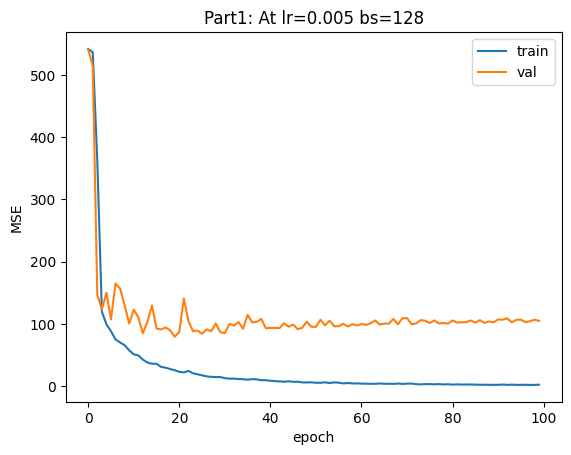

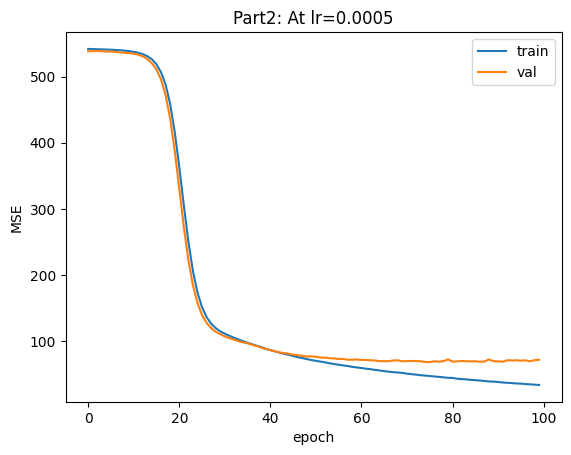

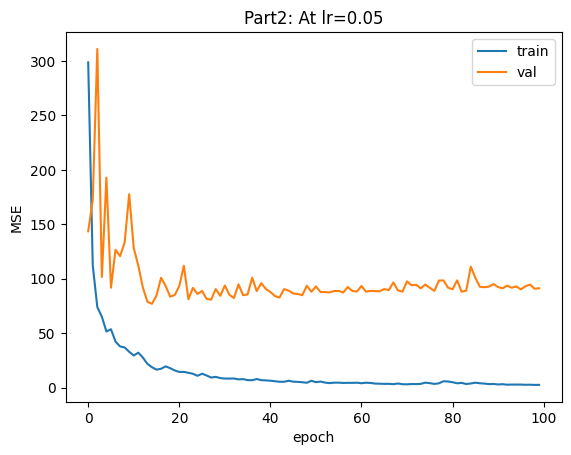

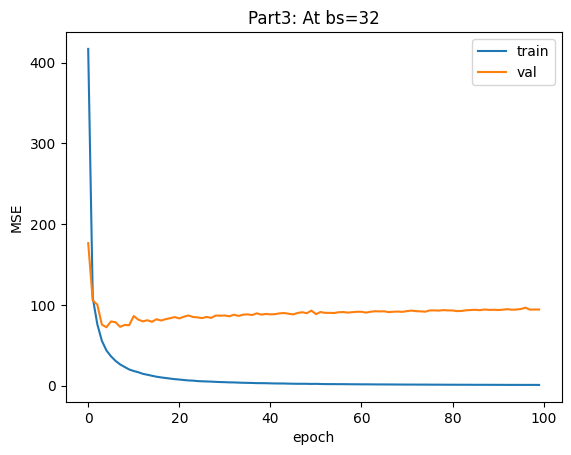

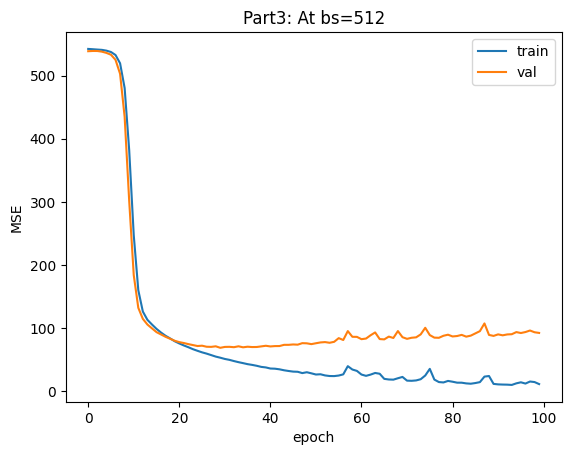

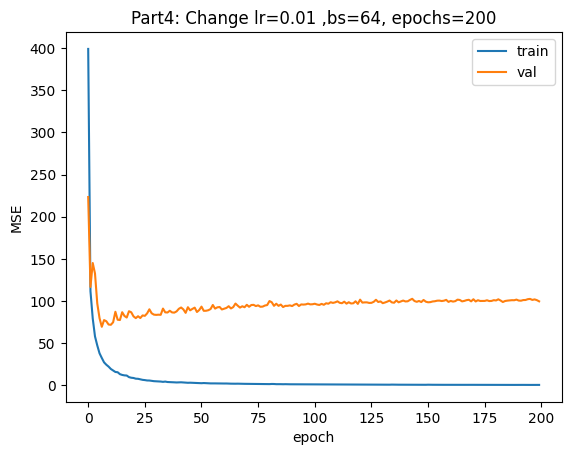

In [ ]:
import torch, math
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

d = 100
n = 6000
alpha = 5.0
sigma = 7.0
theta_star = torch.ones(d)

X = torch.randn(n, d) * math.sqrt(alpha)
Y = X.matmul(theta_star) + torch.randn(n) * sigma
Y = Y.unsqueeze(1)

X_train, Y_train = X[:5000], Y[:5000]
X_val, Y_val = X[5000:], Y[5000:]

class Net(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,50),
            nn.Sigmoid(),
            nn.Linear(50,50),
            nn.Sigmoid(),
            nn.Linear(50,1)
        )
    def forward(self,x): 
        return self.net(x)

def run_experiment(lr=0.005, batch_size=128, epochs=100, weight_decay=1e-3, title=None):
    model = Net(d)
    opt = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    tr_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=batch_size, shuffle=True)
    history = {'train':[], 'val':[]}
    for ep in range(epochs):
        model.train()
        tr_loss = 0.0
        for xb,yb in tr_loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * xb.size(0)
        tr_loss /= len(X_train)
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val), Y_val).item()
        history['train'].append(tr_loss)
        history['val'].append(val_loss)

    plt.figure()
    plt.plot(history['train'], label='train')
    plt.plot(history['val'], label='val')
    plt.xlabel('epoch')
    plt.ylabel('MSE')
    plt.title(title)
    plt.legend()
    plt.show()
    return

# Part 1
run_experiment(lr=0.005, batch_size=128, epochs=100, weight_decay=1e-3, title='Part1: At lr=0.005 bs=128')

# Part 2
run_experiment(lr=0.0005, batch_size=128, epochs=100, weight_decay=1e-3, title='Part2: At lr=0.0005')
run_experiment(lr=0.05, batch_size=128, epochs=100, weight_decay=1e-3, title='Part2: At lr=0.05')

# Part 3
run_experiment(lr=0.005, batch_size=32, epochs=100, weight_decay=1e-3, title='Part3: At bs=32')
run_experiment(lr=0.005, batch_size=512, epochs=100, weight_decay=1e-3, title='Part3: At bs=512')

# Part 4: choose lr = 0.01 batch size = 64, epochs = 200
run_experiment(lr=0.01, batch_size=64, epochs=200, weight_decay=1e-3, title='Part4: Change lr=0.01 ,bs=64, epochs=200')
